In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re

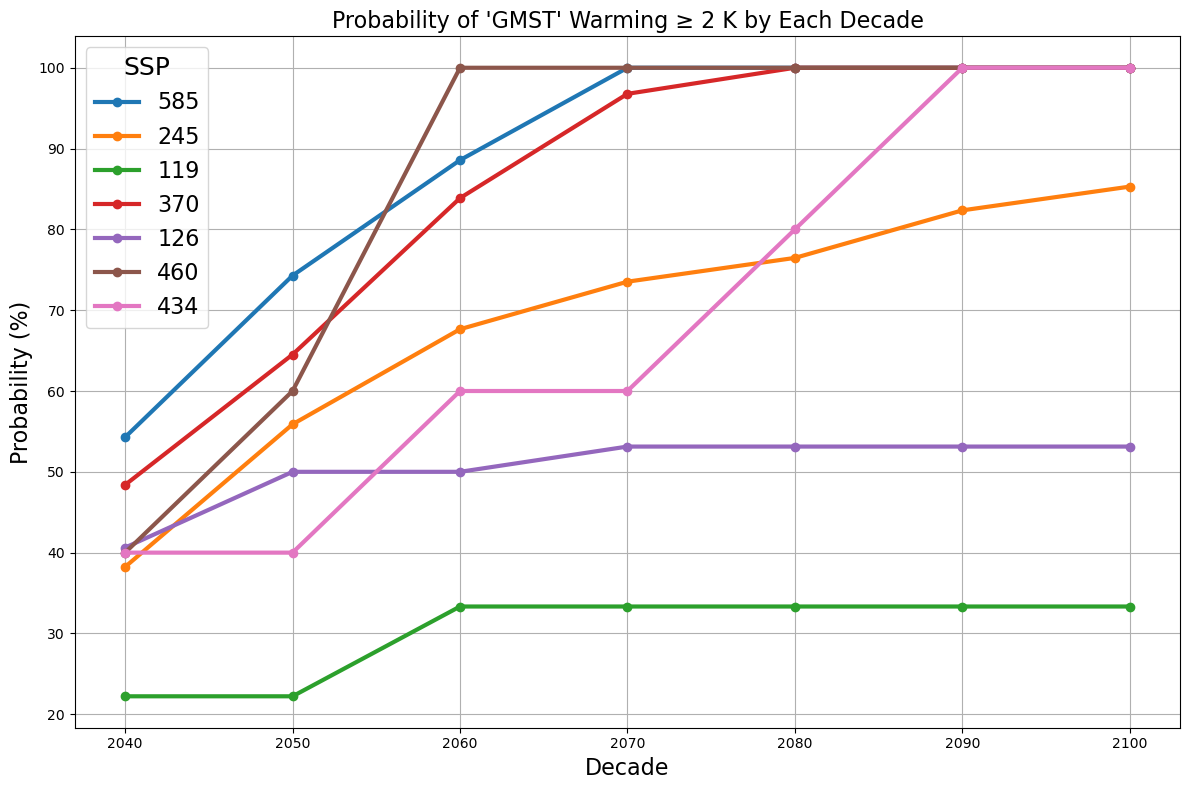

In [7]:
ssp_files = [
    'Documents/Masters Thesis CSV/ssp_585_tas_probability_decades.csv',  # 35 models
    'Documents/Masters Thesis CSV/ssp_245_tas_probability_decades.csv',  # 34 models
    'Documents/Masters Thesis CSV/ssp119_tas_probability_decades.csv',   # 9 models
    'Documents/Masters Thesis CSV/ssp370_tas_probability_decades.csv',   # 31 models
    'Documents/Masters Thesis CSV/ssp126_tas_probability_decades.csv',   # 32 models
    'Documents/Masters Thesis CSV/ssp460_tas_probability_decades.csv',   # 5 models
    'Documents/Masters Thesis CSV/ssp434_tas_probability_decades.csv'    # 5 models
]

# Create an empty dictionary
dfs = {}

# Load each CSV into the dictionary using a regex to extract the experiment ID
for file in ssp_files:
    match = re.search(r'ssp_?(\d+)_tas', file)
    if match:
        experiment = match.group(1)
        dfs[experiment] = pd.read_csv(file)
    else:
        print(f"Could not extract experiment id from {file}")

# Plot data for each file
plt.figure(figsize=(12, 8))

# Loop through each experiment and its DataFrame
for experiment, df in dfs.items():
    plt.plot(
        df['Decade'],
        df['Probability (%)'],
        marker='o',
        markersize=6,
        linewidth=3,
        label=f'{experiment}'
    )

# Add title and labels to plot
plt.title("Probability of 'GMST' Warming ≥ 2 K by Each Decade", fontsize=16)
plt.xlabel("Decade", fontsize=16)
plt.ylabel("Probability (%)", fontsize=16)
plt.legend(title='SSP', loc='upper left', fontsize=16, title_fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig('GCMs_GMST_prob.png', dpi=300)
plt.show()